In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Generating a realistic synthetic dataset mimicking real estate data
np.random.seed(42)
n_samples = 500

sq_ft = np.random.normal(2000, 500, n_samples).astype(int)
bedrooms = np.random.choice([2, 3, 4, 5], size=n_samples, p=[0.2, 0.4, 0.3, 0.1])

In [5]:
location = np.random.choice([0, 1, 2], size=n_samples, p=[0.3, 0.5, 0.2])

In [6]:
# Base price formula + noise to simulate market randomness
price = (
    150000
    + (sq_ft * 120)
    + (bedrooms * 25000)
    + (location * 75000)
    + np.random.normal(0, 30000, n_samples)
)

df = pd.DataFrame(
    {
        "square_footage": sq_ft,
        "bedrooms": bedrooms,
        "location": location,
        "price": price.astype(int),
    }
)

print("First 5 Rows of Housing Dataset")
print(df.head(), "\n")

First 5 Rows of Housing Dataset
   square_footage  bedrooms  location   price
0            2248         4         1  613426
1            1930         3         1  497435
2            2323         3         1  609933
3            2761         5         1  679047
4            1882         4         1  570954 



In [7]:
# One-hot encode the categorical 'location' column (0, 1, 2) into separate dummy variables
df_encoded = pd.get_dummies(df, columns=["location"], drop_first=True, dtype=int)

In [9]:
# Separate features (X) and target (y)
X = df_encoded.drop(columns="price")
y = df_encoded["price"]

In [10]:
# 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [14]:
# Generate Predictions
y_pred = model.predict(X_test_scaled)

In [15]:
#root_mean_squared_error is the standard replacement for mean_squared_error(squared=False)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(" Model Performance Metrics")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}\n")

 Model Performance Metrics
Mean Absolute Error (MAE): $22,113.17
Root Mean Squared Error (RMSE): $26,698.14



In [16]:
#visualizing prediplt.figure(figsize=(8, 6))cted vsactual price
sns.set_theme(style="whitegrid")

<Axes: xlabel='price'>

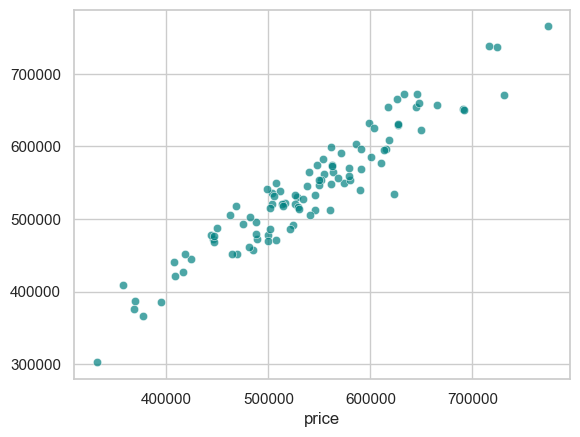

In [17]:
#scatter plot against predicted vs real price
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color="teal", edgecolor="w")

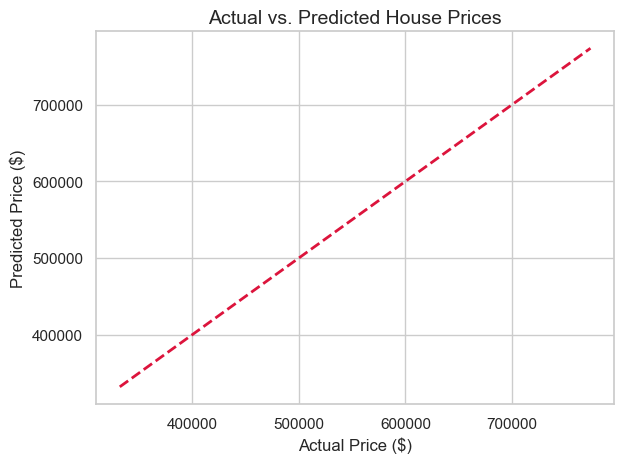

In [18]:
# Perfect prediction line reference line
perfect_line = [y_test.min(), y_test.max()]
plt.plot(perfect_line, perfect_line, linestyle="--", color="crimson", lw=2)

plt.title("Actual vs. Predicted House Prices", fontsize=14)
plt.xlabel("Actual Price ($)", fontsize=12)
plt.ylabel("Predicted Price ($)", fontsize=12)
plt.tight_layout()
plt.show()

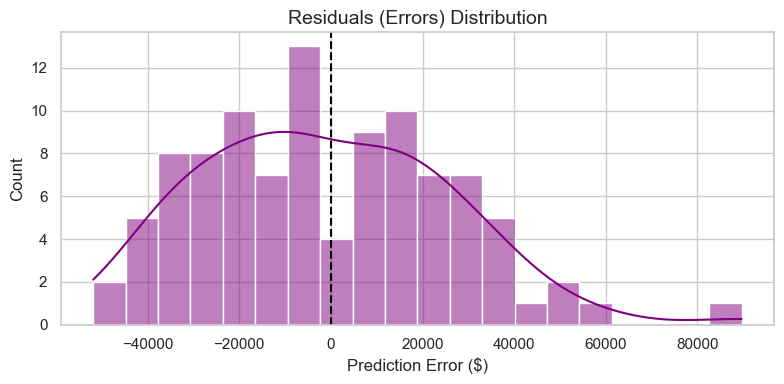

In [19]:
# Residual Plot to evaluate prediction errors
plt.figure(figsize=(8, 4))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color="purple", bins=20)
plt.axvline(0, color="black", linestyle="--")
plt.title("Residuals (Errors) Distribution", fontsize=14)
plt.xlabel("Prediction Error ($)")
plt.tight_layout()
plt.show()